In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [7]:
df = pd.read_csv(r"C:\Users\lenovo\Desktop\تكليف تعلم الاله\plant_growth.csv")

# لنفترض أننا أضفنا متغيرين جديدين: Water وSunlight
# يمكن تعديل القيم حسب بياناتك الفعلية
df['Water'] = np.random.randint(1, 10, size=len(df))
df['Sunlight'] = np.random.randint(1, 10, size=len(df))

# معاينة البيانات
print(df.head())
print(df.describe())
print(df.isnull().sum())

# إزالة الصفوف التي تحتوي على قيم مفقودة في PlantGrowth
df.dropna(subset=['PlantGrowth'], inplace=True)


   Fertilizer  Temperature  Light  Humidity  PlantGrowth  Water  Sunlight
0           1           15      4        70          5.0      9         2
1           2           18      5        68         12.0      5         3
2           3           20      6        65         18.0      7         9
3           2           18      5        68          NaN      9         7
4           3           20      6        65          NaN      4         4
       Fertilizer  Temperature      Light   Humidity  PlantGrowth     Water  \
count   15.000000    15.000000  15.000000  15.000000    10.000000  15.00000   
mean     5.200000    23.200000   8.200000  61.333333    20.600000   5.20000   
std      2.704494     4.229151   2.704494   5.777625     8.167687   2.88345   
min      1.000000    15.000000   4.000000  50.000000     5.000000   1.00000   
25%      3.000000    20.000000   6.000000  58.000000    15.750000   3.00000   
50%      5.000000    24.000000   8.000000  63.000000    22.000000   5.00000   
75%

In [8]:
# المتغيرات المستقلة والتابعة
X = df[['Fertilizer', 'Water', 'Sunlight']]
Y = df['PlantGrowth']

# تقسيم البيانات
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [9]:
poly = PolynomialFeatures(degree=2)  # يمكن تعديل الدرجة
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


In [10]:
model = LinearRegression()
model.fit(x_train_poly, y_train)

# التنبؤ على مجموعة الاختبار
yhat = model.predict(x_test_poly)

# تقييم النموذج
print(f"MSE = {mean_squared_error(y_test, yhat)}")
print(f"R2 Score = {r2_score(y_test, yhat)}")


MSE = 148.67125220744674
R2 Score = -8.291953262965421


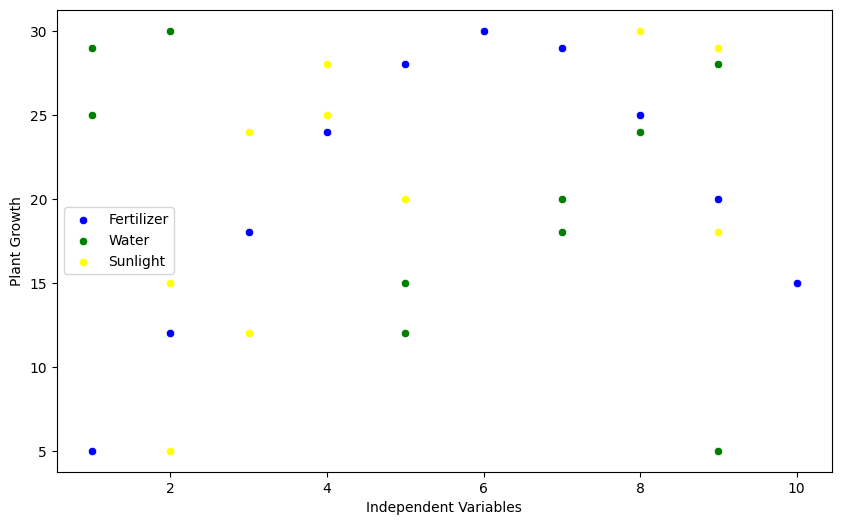

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Fertilizer'], y=Y, color='blue', label='Fertilizer')
sns.scatterplot(x=df['Water'], y=Y, color='green', label='Water')
sns.scatterplot(x=df['Sunlight'], y=Y, color='yellow', label='Sunlight')
plt.xlabel("Independent Variables")
plt.ylabel("Plant Growth")
plt.legend()
plt.show()


In [12]:
new_values = pd.DataFrame({
    'Fertilizer': [11, 12],
    'Water': [5, 6],
    'Sunlight': [8, 7]
})

new_values_poly = poly.transform(new_values)
predictions = model.predict(new_values_poly)
print("Predictions for new values:", predictions)


Predictions for new values: [41.40556561 35.94659236]
